# MACHINE LEARNING - Clustering Project
**Etudiants** : Louis-Gabriel BROSSIER | Victor LOUX | Hoang-Triet NGUYEN

## Introduction
L'hiver approche, les soirées s'allongent, et notre backlog Steam ne va clairement pas se trier tout seul. On a donc besoin d'analyser un dataset de jeux et d'utiliser du clustering pour repérer les pépites parfaites pour hiberner intelligemment.

### Notre jeu de données
*   C'est quoi le dataset ?

Ce dataset a été créé en récupérant des données sur Steam et sur Steam Games Scraper, qui collecte des données à l'aide de l'API Steam et Steam Spy. Elle est à jour jusqu'à mars 2025. Ce dataset nous permet d'avoir une vue globale sur un grand nombre de features pour chacun des jeux du Steam Store.

*   Lister tous les features

 Voici toutes les features que nous avons selectionnés : -appid -name - release_date -required_age -price - dlc_count -metacritic_score -achievements -recommendations -categories -positive -negative -median_playtime_forever -peak_ccu -pct_pos_total

### Notre objectives


## Importation des librairies et du dataset

In [5]:
# Importation des librairies
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("./dataset/Steam_Games_2025.csv")


## Prétraitement des données


In [ ]:
## Supprimer 'appid' du dataset
if ('appid' in df.columns):
    df = df.drop(columns=['appid'])

## Transformer 'release_date' en Année de sortie et changer le nom de la colonne
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df = df.rename(columns={'release_date': 'release_year'})

## Extraire 'single_player' et 'multi_player' de la colonne 'categories'
def extract_category(df: pd.DataFrame, categories_name: str) -> int:
    return 1 if categories_name and df.find(categories_name) != -1 else 0
df['single_player'] = df['categories'].apply(extract_category, args=('Single-player',))
df['multi_player'] = df['categories'].apply(extract_category, args=('Multi-player',))
df = df.drop(columns=['categories'])
df.head(10)

,name,release_year,required_age,price,dlc_count,metacritic_score,achievements,recommendations,positive,negative,median_playtime_forever,peak_ccu,pct_pos_total,num_reviews_total,single_player,multi_player
0,Counter-Strike 2,2012,0,0.00,1,0,1,4401572,7480813,1135108,5174,1212356,86,8632939,0,1
1,PUBG: BATTLEGROUNDS,2017,0,0.00,0,0,37,1732007,1487960,1024436,0,616738,59,2513842,0,1
2,Dota 2,2013,0,0.00,2,90,0,14337,1998462,451338,898,555977,81,2452595,0,1
3,Grand Theft Auto V Legacy,2015,17,0.00,0,96,77,1803063,1719950,250012,7101,117698,87,1803832,1,1
4,Tom Clancy's Rainbow Six® Siege,2015,17,3.99,9,0,0,1165929,1152763,218446,2434,89916,84,1168020,1,1
5,Team Fortress 2,2007,0,0.00,1,92,520,41587,1025633,120619,0,50817,89,1146642,0,1
6,Terraria,2011,0,9.99,2,83,115,1098792,1344773,34460,0,30516,97,1102434,1,1
7,Rust,2018,0,39.99,4,69,92,992825,1043708,152272,3675,200902,87,993856,0,1
8,Garry's Mod,2006,0,5.99,0,0,29,984713,1106689,36727,1173,32384,96,985010,1,1
9,Apex Legends™,2020,0,0.00,0,88,12,1548,660150,322363,667,151844,67,983230,0,1


## Exploration des données

Number of samples: 89618
Number of features: 16


<Figure size 1200x800 with 0 Axes>

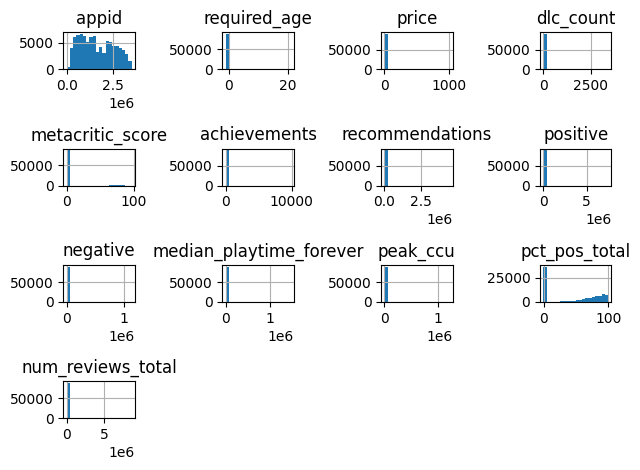

<Axes: xlabel='positive', ylabel='median_playtime_forever'>

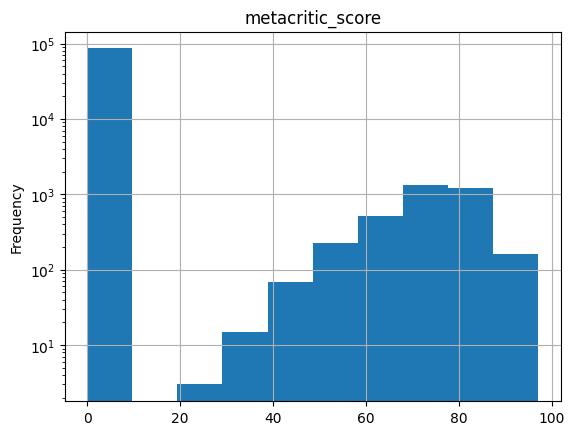

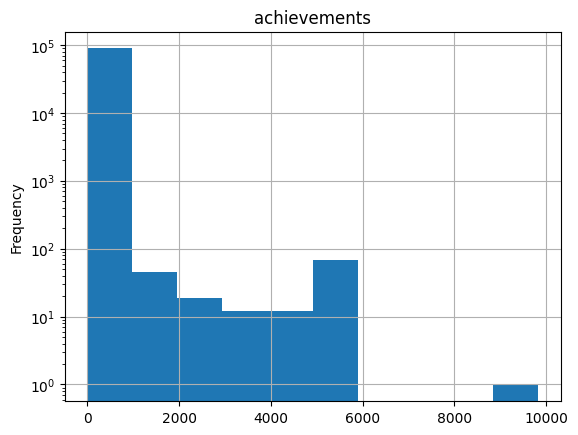

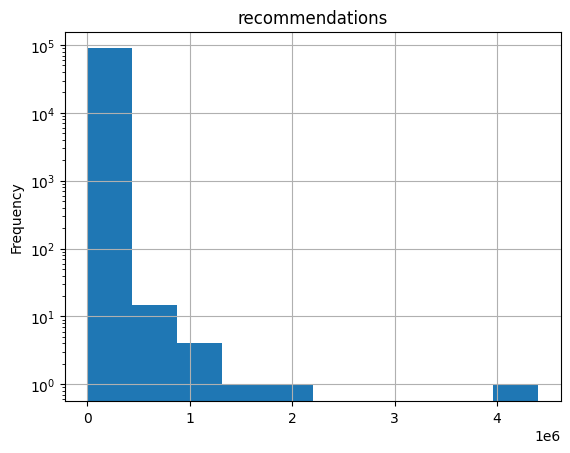

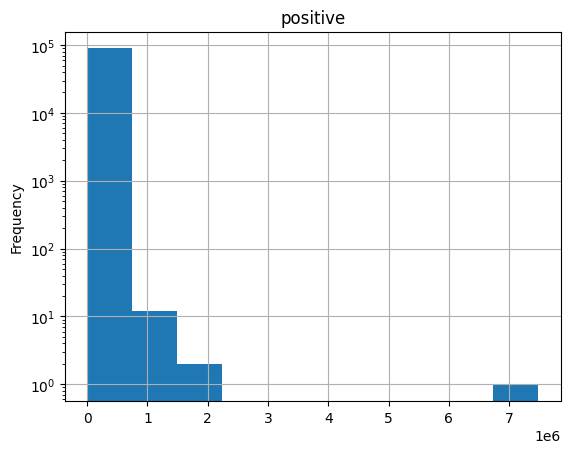

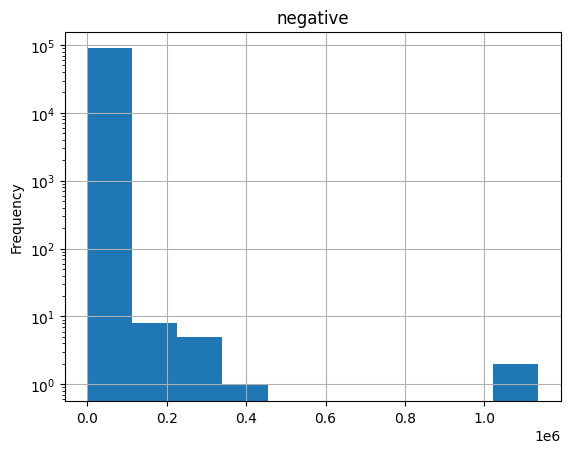

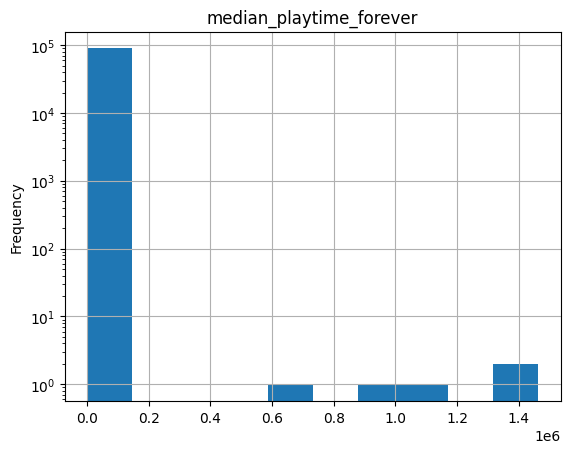

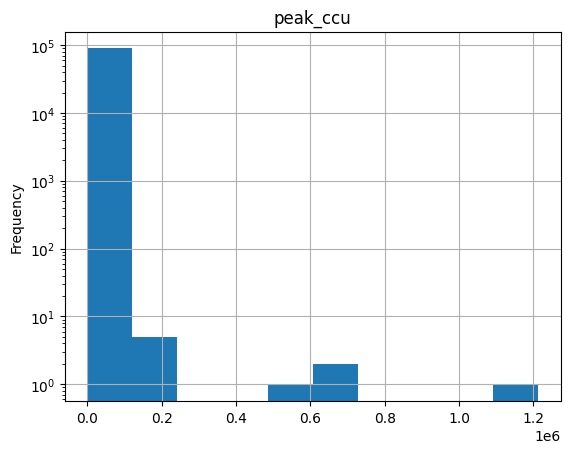

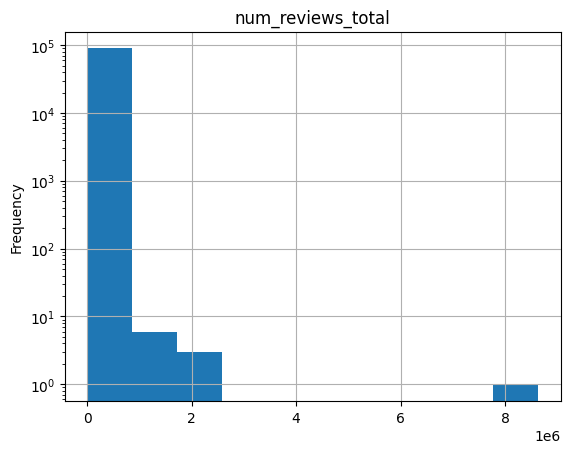

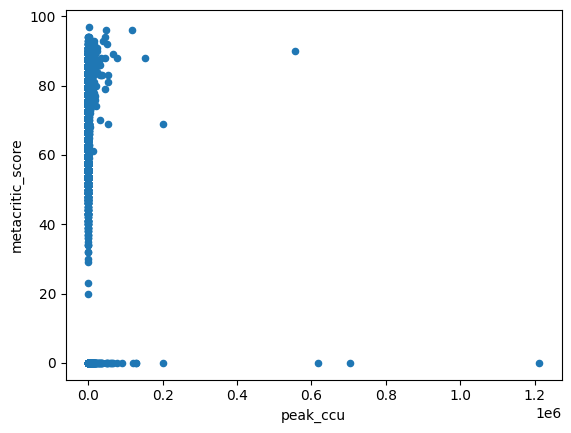

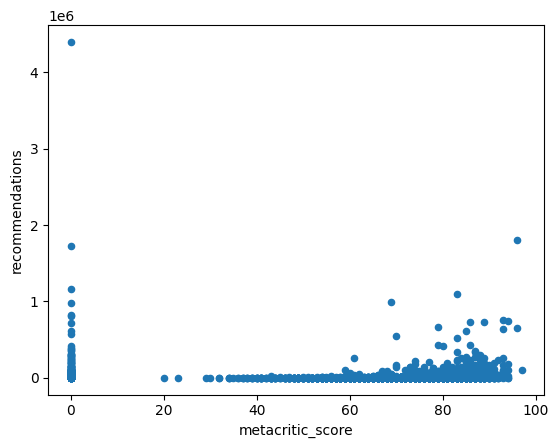

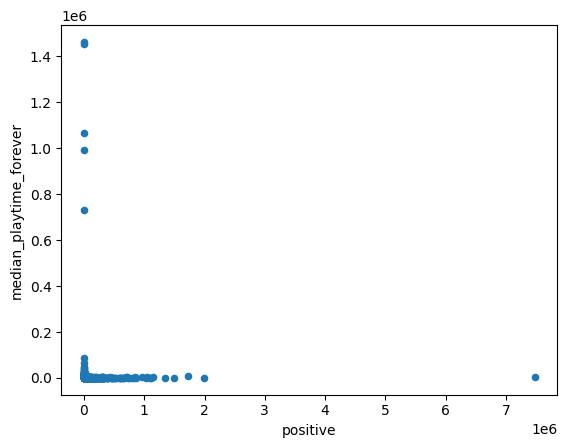

In [12]:
# Nombre d'échantillons et de features
print("Number of samples:", df.shape[0])
print("Number of features:", df.shape[1])

# Distribution des données
plt.figure(figsize=(12, 8))
df[df.columns].hist(bins=20)
plt.tight_layout()
plt.show()
#for the columns with numbers, we can plot the histograms
list=['metacritic_score','achievements','recommendations','positive','negative','median_playtime_forever','peak_ccu','num_reviews_total']

#histogrammes
for x in list:
  plt.figure()
  df[x].plot.hist(logy=True)
  plt.title(x)
  plt.grid()
#même en affichant les données sous l'échelle logarithmique, on observe déjà des pics au niveau de 0 pour les données manquantes(le dataset n'est pas complet)

#covariance & correlation
df2=df[['metacritic_score','achievements','recommendations','positive','negative','median_playtime_forever','peak_ccu','num_reviews_total']]
df2.corr() 
#on observe qu'il y a qlq redondances dans notre jeux de données, les catégories recommendations, positive et num_reviews_total ont une correlation au dessus de 0.9.

df.plot.scatter(x='peak_ccu',y='metacritic_score')
df.plot.scatter(x='metacritic_score',y='recommendations')
df.plot.scatter(x='positive',y='median_playtime_forever')
#en testant qlq combinaisons de catégories en x et y (en évitant de prendre des catégories trop redondantes), 
# on observe que les données ne se regroupe pas bien, se répartissant plus selon l'absence de données que formant des clusters cohérents



In [8]:
#we search for how much features are missing

missing = df.eq(0).sum()
lenght= len(df)
print(missing)
print("lenght total du data set =",lenght)

#on observe que beaucoup de données sont manquante sur ce dataset, en particulier sur les petits jeux qui représentent la majorité des sorties steam.

appid                          0
name                           0
release_date                   0
required_age               88589
price                      14160
dlc_count                  75388
metacritic_score           86071
achievements               41090
recommendations            72881
categories                     0
positive                   19425
negative                   30396
median_playtime_forever    81608
peak_ccu                   70698
pct_pos_total                 18
num_reviews_total              0
dtype: int64
lenght total du data set = 89618


In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [10]:
from sklearn.preprocessing import Normalizer

data = df.drop(columns=['name', 'price', 'release_date'])

normal_values = Normalizer().fit_transform(data.values)
print(normal_values.shape)
print(normal_values)
pca = PCA()
pca.fit(normal_values)
per_var = np.round(pca.explained_variance_ratio_*100, decimals = 1)

plt.figure(figsize = (10,6))
plt.plot(range(1, len(per_var)+1), per_var.cumsum(), marker = "o", linestyle = "--")
plt.grid()
plt.ylabel("Percentage Cumulative of Explained Variance")
plt.xlabel("Number of Components")
plt.title("Explained Variance by Component")
plt.show()

ValueError: could not convert string to float: "['Multi-player', 'Cross-Platform Multiplayer', 'Steam Trading Cards', 'Steam Workshop', 'In-App Purchases', 'Valve Anti-Cheat enabled', 'Stats', 'Remote Play on Phone', 'Remote Play on Tablet', 'Remote Play on TV', 'Steam Timeline']"

In [ ]:
pca = PCA(n_components = 5)
pca.fit(normal_values)

,n_components,5
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None
